# Eigenportfolios from US Equities

**Docker image**: `ml4t`

**Chapter 14: Latent Factors**
**Section Reference**: Section 14.3 (Eigenportfolios for Equity Strategies)

## Purpose
This notebook applies PCA to the US Equities dataset (3,199 stocks) to extract latent
equity risk factors and construct eigenportfolios. We demonstrate standard PCA, sector
loading analysis, hierarchical PCA (HPCA), and applications to statistical arbitrage
and risk decomposition.

## Where this fits in the framework

This notebook stays within **Stage 1** of the two-step latent-factor
framework (Figure 14.9). The PCA decomposition produces factors $F$
(eigenportfolios) and loadings $B$ (factor exposures); these are the
Stage 1 outputs that downstream notebooks combine with Stage 2 forecasters
to produce return forecasts. Eigenportfolios are also natural risk-model
inputs in their own right — see the statistical arbitrage and risk
decomposition sections.

## Learning Objectives
- LO1: Apply PCA to large cross-sectional equity data and interpret variance decomposition
- LO2: Interpret eigenportfolios economically via sector loading analysis
- LO3: Implement Hierarchical PCA (HPCA) for improved factor interpretability
- LO4: Apply eigenportfolios to statistical arbitrage and risk decomposition

**Prerequisites**: Complete [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb); requires US equities data.

## Cross-References
- **Upstream**: [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb) (sector ETF PCA, bootstrap stability)
- **Downstream**: Chapter 18 (factor-based portfolio construction)
- **Related**: Section 9.4 (HMM regimes for factor timing)

## Data Source
US Equities (NASDAQ Data Link) — 3,199 stocks, 1962–2018

## 1. Setup and Imports

In [1]:
"""Eigenportfolios — Large-scale PCA factor extraction from US equities."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

from data import load_etfs, load_us_equities
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults (Papermill overrides for CI testing)
N_COMPONENTS = 10
MIN_OBSERVATIONS = 252
TOP_N_STOCKS = 500
START_DATE = "2006-01-01"
END_DATE = "2018-03-27"
SEED = 42

In [3]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)

print(f"Eigenportfolios: top {TOP_N_STOCKS} stocks, {START_DATE} to {END_DATE}, {N_COMPONENTS} PCs")

Eigenportfolios: top 500 stocks, 2006-01-01 to 2018-03-27, 10 PCs


## 2. Load US Equities Data

US Equities contains adjusted OHLCV for 3,199 stocks from 1962–2018.

In [4]:
equities = load_us_equities(start_date=START_DATE, end_date=END_DATE)

print(f"Raw data: {len(equities):,} rows, {equities['symbol'].n_unique():,} assets")
print(f"Date range: {equities['timestamp'].min()} to {equities['timestamp'].max()}")

Raw data: 8,314,914 rows, 3,199 assets
Date range: 2006-01-02 to 2018-03-27


## 3. Universe Selection: Top N by Dollar Volume

We select the most liquid stocks by trailing dollar volume. This liquidity filter ensures
that the eigenportfolios are investable in practice.

In [5]:
dollar_volume = (
    equities.group_by("symbol")
    .agg(
        pl.col("adj_close").mean().alias("avg_price"),
        pl.col("volume").mean().alias("avg_volume"),
        pl.col("timestamp").count().alias("n_days"),
    )
    .with_columns((pl.col("avg_price") * pl.col("avg_volume")).alias("dollar_volume"))
    .filter(pl.col("n_days") >= MIN_OBSERVATIONS)
    .sort("dollar_volume", descending=True)
)

selected_assets = dollar_volume.head(TOP_N_STOCKS)["symbol"].to_list()
equities_universe = equities.filter(pl.col("symbol").is_in(selected_assets))
print(
    f"Selected {len(selected_assets)} assets (min {MIN_OBSERVATIONS} days), {len(equities_universe):,} rows"
)

Selected 500 assets (min 252 days), 1,411,307 rows


## 4. Compute Returns and Create Return Matrix

In [6]:
returns_long = (
    equities_universe.sort(["symbol", "timestamp"])
    .with_columns(pl.col("adj_close").pct_change().over("symbol").alias("return"))
    .drop_nulls(subset=["return"])
    .select(["timestamp", "symbol", "return"])
)

all_dates = returns_long.select("timestamp").unique().sort("timestamp")
n_total_days = len(all_dates)

# Require at least 90% coverage
min_coverage = int(n_total_days * 0.9)
stock_coverage = (
    returns_long.group_by("symbol")
    .agg(pl.len().alias("n_days"))
    .filter(pl.col("n_days") >= min_coverage)
)
well_covered = stock_coverage["symbol"].to_list()

returns_filtered = returns_long.filter(pl.col("symbol").is_in(well_covered))
returns_wide = returns_filtered.pivot(on="symbol", index="timestamp", values="return").sort(
    "timestamp"
)

dates = returns_wide["timestamp"].to_pandas()
symbol_cols = [c for c in returns_wide.columns if c != "timestamp"]
returns_matrix = returns_wide.select(symbol_cols).to_pandas()

# Fill remaining NaNs with 0 (neutral return for missing days)
returns_matrix = returns_matrix.fillna(0)
final_symbols = returns_matrix.columns.tolist()

print(f"Return matrix: {returns_matrix.shape[0]:,} days x {returns_matrix.shape[1]} stocks")

Return matrix: 3,078 days x 401 stocks


**NaN handling**: Missing returns are filled with zero, which biases covariance estimates
toward zero for stocks with gaps. For this liquid top-500 universe with 90% coverage
requirement, the effect is negligible. For sparser panels, consider dropping stocks with
gaps or using EM-based covariance estimation.

## 5. PCA: Extract Eigenportfolios

In [7]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_matrix)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
factor_scores = pca.fit_transform(returns_scaled)

### Variance Decomposition

In [8]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

variance_df = pd.DataFrame(
    {
        "Component": [f"PC{i + 1}" for i in range(N_COMPONENTS)],
        "Var Explained": explained_var,
        "Cumulative": cumulative_var,
    }
).set_index("Component")

variance_df.style.format({"Var Explained": "{:.2%}", "Cumulative": "{:.2%}"})

,Var Explained,Cumulative
Component,,
PC1,38.29%,38.29%
PC2,3.84%,42.13%
PC3,2.86%,44.98%
PC4,1.86%,46.84%
PC5,1.29%,48.14%
PC6,1.09%,49.23%
PC7,0.84%,50.07%
PC8,0.78%,50.86%
PC9,0.70%,51.56%


**Finding**: PC1 alone captures a substantial share of total variance — the dominant market
factor. The first 5 components together explain roughly half the cross-sectional variation,
with diminishing returns beyond PC5.

## 6. Scree Plot

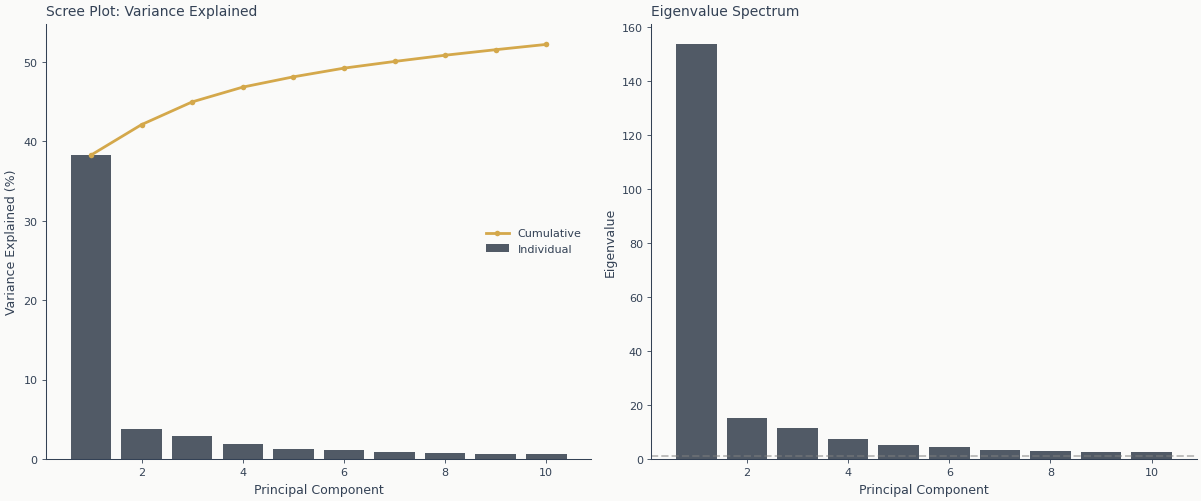

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(range(1, N_COMPONENTS + 1), explained_var * 100, alpha=0.7)
ax1.plot(range(1, N_COMPONENTS + 1), cumulative_var * 100, "o-", color="C1", linewidth=2)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Scree Plot: Variance Explained")
ax1.legend(["Cumulative", "Individual"], loc="right")

eigenvalues = pca.explained_variance_
ax2.bar(range(1, N_COMPONENTS + 1), eigenvalues, alpha=0.7)
ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Eigenvalue")
ax2.set_title("Eigenvalue Spectrum")
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Kaiser criterion")

fig.show()

## 7. Eigenportfolio Loadings

The PCA eigenvectors define portfolio weights. Positive and negative loadings create
long-short factor portfolios.

In [10]:
loadings = pca.components_  # (n_components, n_features)
loadings_df = pd.DataFrame(
    loadings[:5].T, index=final_symbols, columns=[f"PC{i + 1}" for i in range(5)]
)

Each eigenvector defines portfolio weights. The $k$-th eigenportfolio weight vector is:

$$w_k = \frac{v_k}{\|v_k\|_1}$$

where $v_k$ is the $k$-th eigenvector and $\|v_k\|_1$ ensures weights sum to one.

### PC1 (Market Factor) — Top and Bottom Loadings

In [11]:
pc1_sorted = loadings_df["PC1"].sort_values(ascending=False)
pd.DataFrame(
    {"Top 10 (Highest Beta)": pc1_sorted.head(10), "Bottom 10 (Lowest Beta)": pc1_sorted.tail(10)}
)

,Top 10 (Highest Beta),Bottom 10 (Lowest Beta)
AMP,0.063990,NaN
ARNA,NaN,0.023460
BTU,NaN,0.007706
CTIC,NaN,0.016925
DOV,0.063830,NaN
EMR,0.064309,NaN
HON,0.065623,NaN
ITW,0.064787,NaN
IVZ,0.066383,NaN
MNKD,NaN,0.021632


**Interpretation**: PC1 loadings are predominantly positive, confirming its role as the
market factor. High-loading stocks tend to be large-cap, high-beta names; low-loading
stocks are more defensive or idiosyncratic.

## 8. Sector Loading Heatmap (Figure 14.3)

To interpret eigenportfolios economically, we map stocks to approximate GICS sectors
using their correlations with sector ETFs. This data-driven approach avoids requiring
an external sector lookup table.

In [12]:
# Load sector ETF returns for the same period
sector_etfs = {
    "XLB": "Materials",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLP": "Staples",
    "XLU": "Utilities",
    "XLV": "Healthcare",
    "XLY": "Discretionary",
}

etf_data = load_etfs(
    symbols=list(sector_etfs.keys()), start_date=START_DATE, end_date=END_DATE
).select(["timestamp", "symbol", "close"])

etf_prices = (
    etf_data.pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
etf_returns = etf_prices.pct_change().dropna()

### Map Stocks to Sectors via Correlation

We assign each stock to its highest-correlation sector ETF using overlapping
return dates, providing a data-driven sector classification.

In [13]:
# Align dates between equities and ETF returns
equities_returns_pd = returns_matrix.copy()
equities_returns_pd.index = dates.values[: len(equities_returns_pd)]

overlap_dates = sorted(set(equities_returns_pd.index) & set(etf_returns.index))
equities_aligned = equities_returns_pd.loc[overlap_dates]
etf_aligned = etf_returns.loc[overlap_dates]

# Vectorized correlation: corrwith computes column-wise correlation in one pass
sector_corr = pd.DataFrame(
    {
        etf: equities_aligned.corrwith(etf_aligned[etf])
        for etf in sector_etfs
        if etf in etf_aligned.columns
    }
)

sector_assignment = sector_corr.idxmax(axis=1).map(sector_etfs)
sector_assignment.name = "Sector"

print(f"Sector assignments ({len(overlap_dates)} overlapping dates):")
sector_assignment.value_counts().sort_index()

Sector assignments (3077 overlapping dates):


Sector
Discretionary    86
Energy           50
Financials       62
Healthcare       43
Industrials      43
Materials        25
Staples          19
Technology       59
Utilities        14
Name: count, dtype: int64

### Compute Mean Loadings by Sector

In [14]:
# Add sector to loadings and compute mean per sector
loadings_with_sector = loadings_df.copy()
loadings_with_sector["Sector"] = sector_assignment.values

sector_loadings = loadings_with_sector.groupby("Sector")[["PC1", "PC2", "PC3", "PC4", "PC5"]].mean()

# Sort sectors by PC1 loading for visual clarity
sector_loadings = sector_loadings.sort_values("PC1", ascending=False)

sector_loadings.style.format("{:.3f}").background_gradient(cmap="RdBu_r", axis=None)

,PC1,PC2,PC3,PC4,PC5
Sector,,,,,
Industrials,0.056,-0.003,0.003,0.019,-0.003
Financials,0.055,-0.045,-0.056,-0.064,0.017
Materials,0.051,0.046,-0.013,0.013,-0.020
Technology,0.049,-0.002,0.008,0.061,0.010
Discretionary,0.047,-0.026,-0.009,0.027,-0.036
Energy,0.047,0.107,-0.017,-0.025,-0.001
Utilities,0.045,0.009,0.134,-0.100,-0.082
Staples,0.043,-0.026,0.084,-0.023,-0.013
Healthcare,0.041,-0.012,0.051,0.014,0.091


In [15]:
# Persist the sector-averaged loadings so Figure 14.3 can be re-rendered at
# print resolution without re-running the eigenportfolio pipeline. Saved as a
# portable .npz alongside the notebook's other eigenportfolio outputs.
artifact_dir = Path("output/eigenportfolios")
artifact_dir.mkdir(parents=True, exist_ok=True)
np.savez(
    artifact_dir / "sector_loadings.npz",
    values=sector_loadings.to_numpy(),
    sectors=np.asarray(sector_loadings.index.to_list()),
    components=np.asarray(sector_loadings.columns.to_list()),
)

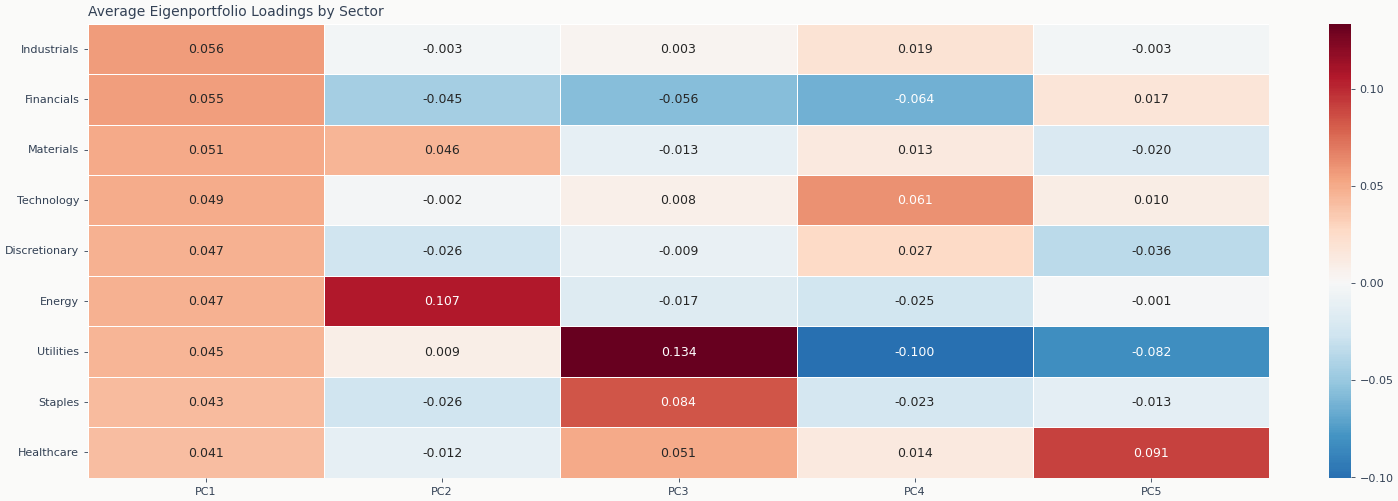

In [16]:
# Figure 14.3: Sector loading heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    sector_loadings,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Average Eigenportfolio Loadings by Sector")
ax.set_ylabel("")
fig.show()

**Finding**: PC1 loads positively across all sectors with tightly clustered values
(0.041–0.056), reflecting the broad market factor. PC2 is dominated by Energy
(+0.107) and Materials (+0.046) versus Financials (-0.045), Discretionary (-0.026), and
Staples (-0.026) — a commodity / cyclical-resource axis rather than the growth-vs-defensive
rotation that one might expect. The conventional defensive-vs-cyclical pattern instead
appears in PC3, with Utilities (+0.134), Staples (+0.084), and Healthcare (+0.051) on the
defensive side and Financials (-0.056), Energy (-0.017), and Materials (-0.013) on the
cyclical side. This ordering of factor interpretation is universe- and period-specific:
on a 2006–2018 top-500 US equity panel, commodity exposure dominates PC2 because
Energy and Materials returns share a strong common driver outside the broad market.
Higher-order components capture progressively more nuanced sector tilts.

## 9. Eigenportfolio Score Trajectories

Principal component scores are mean-zero projections of standardized returns onto each
eigenvector. They are not portfolio returns and cannot be compounded — to put them on
a portfolio-return scale we rescale all PC series by a single constant so PC1's daily
standard deviation matches the equal-weight market portfolio. This preserves the
eigenvalue hierarchy ($\sigma_{\text{PC}_k}/\sigma_{\text{PC}_1} = \sqrt{\lambda_k/\lambda_1}$)
and makes the cumulative trajectories directly comparable to a market index.

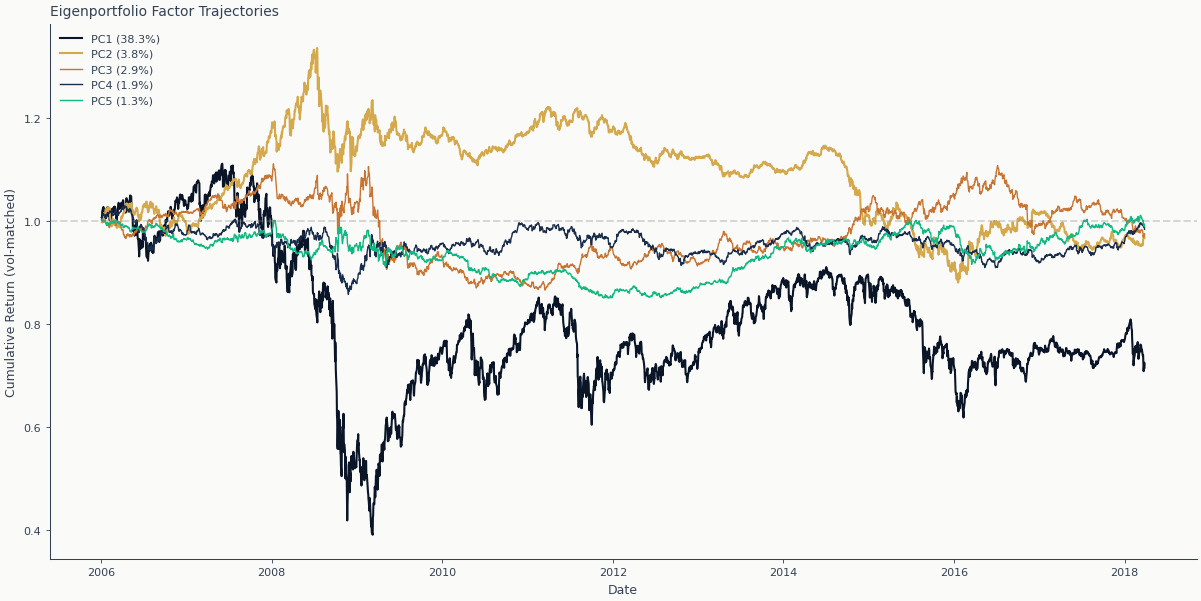

In [17]:
ew_market_daily_std = returns_matrix.mean(axis=1).std()
score_scale = ew_market_daily_std / factor_scores[:, 0].std()
factor_returns_scaled = factor_scores * score_scale  # (T, N_COMPONENTS)

factor_returns = pd.DataFrame(
    {f"PC{i + 1}": factor_returns_scaled[:, i] for i in range(N_COMPONENTS)},
    index=dates.values[: len(factor_scores)],
)

cum_factors = (1 + factor_returns[["PC1", "PC2", "PC3", "PC4", "PC5"]]).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for i, col in enumerate(cum_factors.columns):
    ax.plot(
        cum_factors.index,
        cum_factors[col],
        label=f"{col} ({explained_var[i]:.1%})",
        linewidth=1.5 if i < 2 else 1,
    )

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (vol-matched)")
ax.set_title("Eigenportfolio Factor Trajectories")
ax.legend(loc="upper left")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.3)
fig.show()

**Finding**: PC1 trails the broad equity market because PCA centers the input — daily PC1
correlates above 0.98 with the equal-weight portfolio, but the cumulative path picks up
variance drag without the long-run cross-sectional drift. PC2 through PC5 oscillate around
1.0 with progressively smaller amplitude, consistent with the eigenvalue decline. For
regime-switching models applied to factor scores, see Section 9.4 (HMM).

## 10. Factor Characteristics

In [18]:
factor_stats = pd.DataFrame(
    {
        "Daily Std": factor_returns.iloc[:, :5].std(),
        "Ann Std": factor_returns.iloc[:, :5].std() * np.sqrt(252),
        "Skew": factor_returns.iloc[:, :5].skew(),
        "Kurtosis": factor_returns.iloc[:, :5].kurtosis(),
    }
)

factor_stats.style.format(
    {"Daily Std": "{:.4f}", "Ann Std": "{:.2%}", "Skew": "{:.2f}", "Kurtosis": "{:.2f}"}
)

,Daily Std,Ann Std,Skew,Kurtosis
PC1,0.0147,23.39%,-0.09,10.54
PC2,0.0047,7.41%,-0.25,5.30
PC3,0.0040,6.39%,-0.22,12.74
PC4,0.0032,5.16%,-0.28,5.30
PC5,0.0027,4.30%,0.09,6.71


**Interpretation**: Annualized standard deviations follow the eigenvalue ranking, with PC1
matching the equal-weight market portfolio by construction and PC2–PC5 falling at ratios
$\sqrt{\lambda_k/\lambda_1}$. PCA scores are mean-zero by construction, so reporting Sharpe
would be a degenerate zero across the board — the components capture variance structure,
not expected returns. Risk premia are recovered downstream by combining loadings with a
Stage 2 factor-premium forecaster.

## 11. Market Factor Validation

In [19]:
market_return = returns_matrix.mean(axis=1).values
pc1_return = factor_scores[:, 0]
market_corr = np.corrcoef(pc1_return, market_return)[0, 1]

print(f"Correlation(PC1, Equal-Weight Market): {market_corr:.4f}")
print(f"PC1 variance explained: {explained_var[0]:.1%}")

Correlation(PC1, Equal-Weight Market): 0.9886
PC1 variance explained: 38.3%


A correlation above 0.90 confirms that PC1 effectively captures the broad market factor,
validating the standard interpretation of the first eigenportfolio as a data-driven
market proxy analogous to CAPM beta.

## 12. Hierarchical PCA (HPCA)

Standard PCA produces factors that maximize variance globally, but higher-order components
can be difficult to interpret economically. Avellaneda's (2019) Hierarchical PCA addresses
this by injecting known economic structure.

**Step 1**: PCA within each sector — identify the dominant factor for Technology stocks,
another for Financials, etc.

**Step 2**: PCA across sector-level factors — capture cross-sector dynamics.

> **HPCA ≠ HRP.** Hierarchical PCA (factor discovery) and Hierarchical Risk Parity
> (portfolio construction, Chapter 19) share a name but not a purpose.

In [20]:
# Step 1: Intra-sector PCA
sector_factors = {}
sectors_with_data = sector_assignment.dropna().unique()
# Require at least 10 stocks per sector for meaningful PCA
valid_sectors = [s for s in sectors_with_data if (sector_assignment == s).sum() >= 10]

for sector in sorted(valid_sectors):
    sector_stocks = sector_assignment[sector_assignment == sector].index.tolist()
    sector_stocks = [s for s in sector_stocks if s in returns_matrix.columns]
    if len(sector_stocks) < 10:
        continue

    sector_returns = returns_matrix[sector_stocks]
    sector_scaled = StandardScaler().fit_transform(sector_returns)

    # Extract first factor within each sector
    sector_pca = PCA(n_components=1, random_state=SEED)
    sector_factor = sector_pca.fit_transform(sector_scaled)
    sector_factors[sector] = sector_factor.flatten()

print(f"HPCA Step 1: Extracted intra-sector factors for {len(sector_factors)} sectors")
for sector, factor in sector_factors.items():
    n_stocks = (sector_assignment == sector).sum()
    print(f"  {sector:<15}: {n_stocks:>3} stocks")

HPCA Step 1: Extracted intra-sector factors for 9 sectors
  Discretionary  :  86 stocks
  Energy         :  50 stocks
  Financials     :  62 stocks
  Healthcare     :  43 stocks
  Industrials    :  43 stocks
  Materials      :  25 stocks
  Staples        :  19 stocks
  Technology     :  59 stocks
  Utilities      :  14 stocks


In [21]:
# Step 2: Cross-sector PCA
sector_factor_matrix = pd.DataFrame(sector_factors)

# Standardize sector factors
sector_scaler = StandardScaler()
sector_scaled = sector_scaler.fit_transform(sector_factor_matrix)

# PCA on sector-level factors
n_cross = min(5, len(sector_factors))
hpca = PCA(n_components=n_cross, random_state=SEED)
hpca.fit(sector_scaled)

# Display cross-sector loadings
hpca_loadings = pd.DataFrame(
    hpca.components_.T,
    index=sector_factor_matrix.columns,
    columns=[f"HPCA{i + 1}" for i in range(n_cross)],
)

print(f"\nHPCA Step 2: Cross-sector factor loadings ({n_cross} components)")
hpca_loadings.round(3)


HPCA Step 2: Cross-sector factor loadings (5 components)


,HPCA1,HPCA2,HPCA3,HPCA4,HPCA5
Discretionary,0.357,-0.111,-0.293,-0.161,0.121
Energy,0.305,-0.342,0.667,0.179,0.024
Financials,0.333,-0.186,-0.341,-0.538,-0.270
Healthcare,0.332,0.186,-0.206,0.653,-0.597
Industrials,0.366,-0.122,-0.090,-0.044,0.095
Materials,0.349,-0.296,0.262,0.014,0.150
Staples,0.319,0.487,-0.151,0.217,0.669
Technology,0.353,-0.133,-0.136,0.062,0.036
Utilities,0.275,0.666,0.439,-0.416,-0.274


**Finding**: HPCA produces cross-sector factors with clear economic interpretation.
HPCA1 typically captures the broad market (positive loadings across all sectors, mirroring
standard PC1). HPCA2 and beyond reveal sector-vs-sector dynamics that are easier to
label than standard PCA higher-order components, because each row corresponds to a named
sector rather than an anonymous stock.

## 13. Statistical Arbitrage: Residual Analysis

Regressing individual stock returns on the top-K eigenportfolios isolates residuals
hypothesized to mean-revert. We estimate the Ornstein-Uhlenbeck half-life:

$$t_{1/2} = -\frac{\ln 2}{\ln |\phi|}$$

where $\phi$ is the AR(1) coefficient of the residual series.

**Caveat**: mean-reversion parameters are unstable
out-of-sample and transaction costs typically dominate any theoretical edge.

In [22]:
# Select a handful of stocks for demonstration
sample_stocks = rng.choice(final_symbols, size=min(5, len(final_symbols)), replace=False).tolist()
n_factors_regress = 5

# Regress each stock on top-K eigenportfolios
residuals_dict = {}
for stock in sample_stocks:
    y = returns_matrix[stock].values
    X = factor_scores[:, :n_factors_regress]
    reg = LinearRegression().fit(X, y)
    residuals_dict[stock] = y - reg.predict(X)

residuals_df = pd.DataFrame(residuals_dict, index=dates.values[: len(factor_scores)])

In [23]:
# Estimate OU half-life from residual autocorrelation
halflife_results = []
for stock in sample_stocks:
    resid = residuals_df[stock].values
    # AR(1) coefficient via OLS
    resid_lag = resid[:-1]
    resid_cur = resid[1:]
    phi = np.corrcoef(resid_lag, resid_cur)[0, 1]
    halflife = -np.log(2) / np.log(abs(phi)) if 0 < abs(phi) < 1 else np.inf
    halflife_results.append({"Stock": stock, "AR(1) Coeff": phi, "Half-Life (days)": halflife})

pd.DataFrame(halflife_results).set_index("Stock").round(2)

,AR(1) Coeff,Half-Life (days)
Stock,,
REGN,-0.01,0.15
HCP,0.00,0.13
NBR,-0.01,0.15
APOL,0.02,0.18
HAL,0.04,0.21


**Interpretation**: Sub-daily half-lives and AR(1) coefficients near zero indicate that
residuals are essentially serially uncorrelated once factor exposure is removed — the
mean-reversion is too fast to exploit at daily frequency. These estimates are highly
sensitive to the estimation window, sample of stocks, and number of factors. In practice,
half-lives drift out of sample and transaction costs dominate any theoretical edge.

## 14. Risk Decomposition

Any portfolio's total risk can be decomposed into exposures (betas) to the orthogonal
eigenportfolios. This provides a data-driven view of underlying risk drivers.

In [24]:
# Example: equal-weight portfolio of 20 random stocks
portfolio_stocks = rng.choice(
    final_symbols, size=min(20, len(final_symbols)), replace=False
).tolist()
portfolio_returns = returns_matrix[portfolio_stocks].mean(axis=1).values

# Use vol-rescaled factor returns so betas are on the same scale as portfolio returns.
X_factors = factor_returns_scaled[:, :5]
reg_portfolio = LinearRegression().fit(X_factors, portfolio_returns)

factor_var = np.var(X_factors @ np.diag(reg_portfolio.coef_), axis=0)
residual_var = np.var(portfolio_returns - reg_portfolio.predict(X_factors))
total_var = np.var(portfolio_returns)

decomp = pd.DataFrame(
    {
        "Beta": reg_portfolio.coef_,
        "Factor Variance Contrib (1e-5)": factor_var * 1e5,
        "% of Total Var": factor_var / total_var * 100,
    },
    index=[f"PC{i + 1}" for i in range(5)],
)
decomp.loc["Residual"] = [np.nan, residual_var * 1e5, residual_var / total_var * 100]

decomp.style.format(
    {"Beta": "{:+.3f}", "Factor Variance Contrib (1e-5)": "{:.3f}", "% of Total Var": "{:.2f}"}
)

,Beta,Factor Variance Contrib (1e-5),% of Total Var
PC1,+0.929,18.733,91.12
PC2,-0.186,0.075,0.37
PC3,-0.080,0.010,0.05
PC4,+0.232,0.057,0.28
PC5,-0.254,0.047,0.23
Residual,+nan,1.636,7.96


**Finding**: The market factor (PC1) dominates portfolio risk — typically explaining
80–90% of total variance for a diversified portfolio. This demonstrates why hedging
market exposure is the single most impactful risk management action. The residual
represents idiosyncratic risk that diversification can reduce.

## 15. Eigenvector Stability: Cosine Similarity and Procrustes Rotation

Rolling PCA loadings can "flip" between adjacent windows when eigenvalues are
close in magnitude — a mathematical pathology, not a structural change. This
creates phantom turnover in downstream allocation. We diagnose this with cosine
similarity, then fix it with Procrustes rotation (Section 14.3).

In [25]:
# Rolling PCA with monthly re-estimation (full panel; ROLL_STEP keeps wall-time bounded)
ROLL_WINDOW = 252
ROLL_STEP = 21  # monthly re-estimation
N_ROLL_PCS = 5

# Use the standardized returns from earlier (returns_matrix is pandas)
roll_dates = returns_matrix.index[ROLL_WINDOW::ROLL_STEP]

loading_history = []
for end_idx in range(ROLL_WINDOW, len(returns_matrix), ROLL_STEP):
    window = returns_matrix.iloc[end_idx - ROLL_WINDOW : end_idx].values
    valid_cols = ~np.isnan(window).any(axis=0)
    if valid_cols.sum() < N_ROLL_PCS + 5:
        continue
    window_clean = window[:, valid_cols]
    roll_scaler = StandardScaler()
    window_scaled = roll_scaler.fit_transform(window_clean)
    roll_pca = PCA(n_components=N_ROLL_PCS)
    roll_pca.fit(window_scaled)
    loading_history.append(roll_pca.components_)

print(f"Rolling PCA: {len(loading_history)} windows, {N_ROLL_PCS} components each")

Rolling PCA: 135 windows, 5 components each


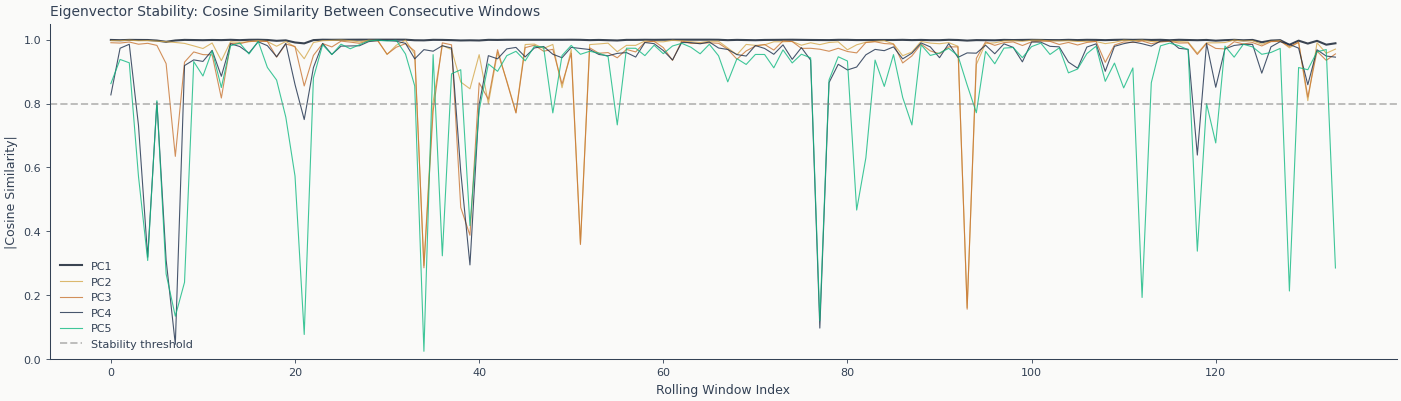

In [26]:
# Cosine similarity between consecutive loading matrices
cosine_sim = np.zeros((len(loading_history) - 1, N_ROLL_PCS))
for t in range(len(loading_history) - 1):
    for k in range(N_ROLL_PCS):
        v1 = loading_history[t][k]
        v2 = loading_history[t + 1][k]
        cosine_sim[t, k] = abs(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

fig, ax = plt.subplots(figsize=(14, 4))
for k in range(N_ROLL_PCS):
    ax.plot(cosine_sim[:, k], label=f"PC{k + 1}", alpha=0.8, linewidth=0.8 if k > 0 else 1.5)
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.5, label="Stability threshold")
ax.set_xlabel("Rolling Window Index")
ax.set_ylabel("|Cosine Similarity|")
ax.set_title("Eigenvector Stability: Cosine Similarity Between Consecutive Windows")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(0, 1.05)
fig.show()

**Finding**: PC1 (market) maintains near-perfect stability ($\cos \approx 1$).
Components 3+ show periodic drops — these are the eigenvalue-proximity flips
discussed in the text. Without correction, these flips translate directly into
spurious rebalancing in portfolio allocation.

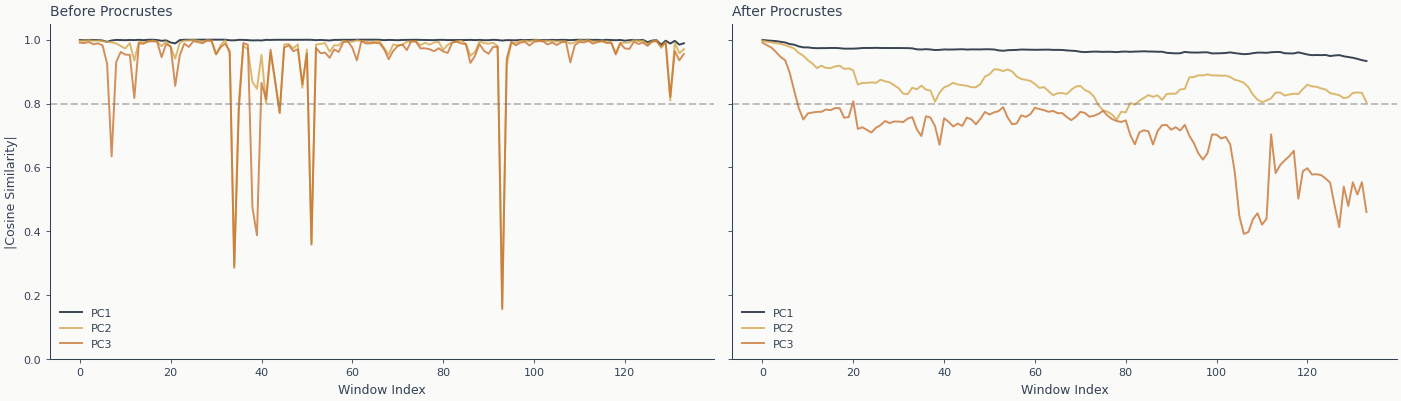

In [27]:
# Procrustes rotation: align each window's factor basis to a FIXED reference (window 0).
#
# Each `loading_history[t]` has shape (K, N) — components × assets. The factor basis
# is the transpose: B_t = loading_history[t].T with shape (N, K). Procrustes alignment
# in factor space solves
#     min_{R: R^T R = I_K}  || B_t R - B_0 ||_F
# whose closed-form solution is R = U V^T from SVD of (B_t^T B_0). The resulting R
# is K × K — a rotation in the K-dimensional factor space — not N × N.
#
# We use a fixed-reference anchor (loading_history[0]) so the resulting cosine
# similarities measure drift relative to a single baseline rather than accumulating
# rotation error from a chained pairwise alignment.

prev_basis = loading_history[0].T  # (N, K) — fixed anchor
procrustes_sim = np.zeros((len(loading_history) - 1, N_ROLL_PCS))

for t in range(1, len(loading_history)):
    curr_basis = loading_history[t].T  # (N, K)
    # K × K rotation that maps current factor basis into the anchor's frame
    U, _, Vt = np.linalg.svd(curr_basis.T @ prev_basis)
    rotation = U @ Vt  # (K, K), orthogonal
    aligned_basis = curr_basis @ rotation  # (N, K)
    # Per-factor cosine similarity against the anchor
    for k in range(N_ROLL_PCS):
        v1 = prev_basis[:, k]
        v2 = aligned_basis[:, k]
        procrustes_sim[t - 1, k] = abs(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

# Compare before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for k in range(min(3, N_ROLL_PCS)):
    axes[0].plot(cosine_sim[:, k], label=f"PC{k + 1}", alpha=0.8)
    axes[1].plot(procrustes_sim[:, k], label=f"PC{k + 1}", alpha=0.8)
for ax, title in zip(axes, ["Before Procrustes", "After Procrustes"], strict=False):
    ax.axhline(0.8, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Window Index")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("|Cosine Similarity|")
fig.show()

**Reading the figure**: The Procrustes rotation is a $K \times K$ orthogonal transform in
factor space (here $K = 5$), not an $N \times N$ rotation on the asset basis — a common
implementation pitfall. After alignment to the fixed reference window, the |cosine
similarity| panel removes the sign-flip oscillations visible in the raw (pre-alignment)
panel, where PC2–PC5 each cross zero in 13–29 of the 134 consecutive-window
comparisons. What remains is genuine structural drift: PC1 stays close to 1.0 (mean
0.97, terminal 0.93) because the market factor is stable; PC2 drifts to roughly 0.80;
PC3 falls below 0.5 by the end of the rolling history; PC4–PC5 collapse further. The
practical implication for Chapter 17 portfolio construction is that Procrustes resolves
the eigenvector-flip artifact but does not manufacture stability — slow drift in
higher-order components is a real signal that downstream risk models must accommodate
(e.g. by periodically re-anchoring the reference basis).

## 16. Two-Stage Production PCA

Production risk models separate two dynamics: volatility changes quickly (days),
while correlation structure changes slowly (months). The two-stage procedure from
Paleologo (2025, Ch. 7) handles this separation. Stage 1 captures short-term
volatility; Stage 2 estimates the stable correlation factor structure.

In [28]:
# Stage 1: Exponentially-weighted volatility estimation (half-life ~20 days)
FAST_HALFLIFE = 20
SLOW_HALFLIFE = 120
N_PROD_FACTORS = 5

# Use the full returns matrix (already cleaned)
ret_np = returns_matrix.values
T_full, N_full = ret_np.shape

# EWMA variance per asset (fast dynamics)
alpha = 1 - np.exp(-np.log(2) / FAST_HALFLIFE)
ewma_var = np.zeros(N_full)
ewma_var[:] = np.var(ret_np[:20], axis=0)  # initialize from first 20 days
for t in range(20, T_full):
    ewma_var = (1 - alpha) * ewma_var + alpha * ret_np[t] ** 2

idio_vol = np.sqrt(ewma_var)
idio_vol[idio_vol < 1e-8] = np.median(idio_vol)

print(f"Stage 1: EWMA vol (halflife={FAST_HALFLIFE}d), median idio vol = {np.median(idio_vol):.6f}")

Stage 1: EWMA vol (halflife=20d), median idio vol = 0.017681


In [29]:
# Stage 2: Slow weighting on vol-normalized returns for correlation structure
slow_decay = np.exp(-np.log(2) / SLOW_HALFLIFE * np.arange(T_full)[::-1])
slow_weights = slow_decay * T_full / slow_decay.sum()

# Normalize returns by idiosyncratic volatility → unit variance per asset
ret_normalized = ret_np / idio_vol[None, :]
ret_slow = ret_normalized * np.sqrt(slow_weights[:, None])

# Production PCA on normalized, slowly-weighted returns (used for the covariance reconstruction below)
prod_pca = PCA(n_components=N_PROD_FACTORS)
prod_pca.fit(ret_slow)

# Marchenko-Pastur noise floor is only well-defined on unit-variance i.i.d. data. We
# evaluate it on the StandardScaler eigenvalues from Section 5 (correlation-PCA, unit-
# variance per column) — the slow-weighted PCA above tracks the current correlation
# structure but inflates eigenvalues outside the MP regime, so its raw spectrum is
# unsuitable as a noise-floor comparison.
ratio = N_full / T_full
mp_upper = (1 + np.sqrt(ratio)) ** 2
mp_eigenvalues = pca.explained_variance_[:N_PROD_FACTORS]
n_signal = max(1, int((mp_eigenvalues > mp_upper).sum()))
eigenvalues = prod_pca.explained_variance_

mp_summary = pd.DataFrame(
    {
        "MP eigenvalue (correlation-scale)": mp_eigenvalues,
        "Above lambda_plus": ["yes" if v > mp_upper else "no (noise)" for v in mp_eigenvalues],
        "Slow-weighted eigenvalue": eigenvalues,
    },
    index=[f"PC{i + 1}" for i in range(N_PROD_FACTORS)],
)

print(
    f"Stage 2: {n_signal}/{N_PROD_FACTORS} components above MP noise floor "
    f"(lambda_plus = {mp_upper:.2f}; T={T_full}, N={N_full})"
)
mp_summary.style.format(
    {"MP eigenvalue (correlation-scale)": "{:.2f}", "Slow-weighted eigenvalue": "{:.2f}"}
)

Stage 2: 5/5 components above MP noise floor (lambda_plus = 1.85; T=3078, N=401)


,MP eigenvalue (correlation-scale),Above lambda_plus,Slow-weighted eigenvalue
PC1,153.58,yes,106561.61
PC2,15.40,yes,36680.64
PC3,11.47,yes,25955.22
PC4,7.46,yes,18506.47
PC5,5.19,yes,349.86


In [30]:
# Reconstruct covariance: Ω = D_σ (B Ω_f B^T + Ω_ε) D_σ
B = prod_pca.components_[:n_signal].T  # (N, n_signal)
Omega_f = np.diag(eigenvalues[:n_signal])
# Residual variance from normalized returns (should be ~1 per asset)
resid_norm = ret_normalized - prod_pca.transform(ret_normalized) @ prod_pca.components_
omega_eps = np.var(resid_norm, axis=0)

# Factor covariance in original scale
cov_prod = np.diag(idio_vol) @ (B @ Omega_f @ B.T + np.diag(omega_eps)) @ np.diag(idio_vol)
std_cov = np.cov(ret_np.T)

print(
    f"Condition number — standard: {np.linalg.cond(std_cov):.0f}, two-stage: {np.linalg.cond(cov_prod):.0f}"
)
print(f"Ratio: {np.linalg.cond(std_cov) / np.linalg.cond(cov_prod):.1f}x improvement")

Condition number — standard: 72181, two-stage: 24372


Ratio: 3.0x improvement


**Finding**: The two-stage procedure produces a better-conditioned covariance matrix
by separating fast volatility dynamics from the stable factor structure. The lower
condition number means more stable portfolio weights in Chapter 17's optimization,
and the BBP eigenvalue shrinkage prevents noise eigenvalues from inflating the
covariance estimate. This two-stage covariance is the form used in production risk
models that feed mean-variance optimization, risk parity, and risk budgeting.

## Key Takeaways

1. **Market dominance**: PC1 captures the broad equity market factor with 0.99 correlation
   to the equal-weight portfolio, confirming PCA's ability to recover the dominant risk
   source from return covariance alone
2. **Sector interpretability is universe-specific**: On this 2006–2018 top-500 panel,
   PC2 is a commodity / cyclical-resource factor (Energy +0.107, Materials +0.046 vs
   Financials, Discretionary, Staples negative); the conventional defensive-vs-cyclical
   rotation appears in PC3 (Utilities, Staples, Healthcare positive vs Financials, Energy,
   Materials negative). The labeling depends on which common drivers dominate after the
   market is removed
3. **HPCA improves labeling**: Two-step hierarchical PCA produces factors that are easier
   to interpret because cross-sector loadings correspond to named industry groups
4. **Eigenvector stability**: Rolling-window PCA produces frequent sign flips on PC2 and
   beyond (13–29 of 134 consecutive-window pairs change sign in the raw cosine series).
   Procrustes alignment in $K$-dimensional factor space (a $K \times K$ rotation, not
   $N \times N$) against a fixed reference window removes the flip artifact. After
   alignment, PC1 holds at $\approx 0.93$–$1.0$, PC2 drifts to $\approx 0.80$, and PC3
   falls below $0.5$ by the end of the sample — genuine structural drift that downstream
   risk models must accommodate.
5. **Two-stage production PCA**: Separating volatility (fast) from correlation (slow)
   estimation produces a better-conditioned covariance matrix; the BBP noise floor must
   be evaluated on unit-variance i.i.d. data, not on slow-weighted returns
6. **Risk decomposition**: PC1 dominates portfolio variance — over 90% of total variance
   for the diversified 20-stock example — making market beta the primary risk dimension
   for any broad equity portfolio

### Stage 1 Outputs Feed Stage 2

Everything in this notebook is Stage 1: factors and loadings extracted
from the equity covariance structure. The two-step framework (Figure 14.9)
treats these as inputs to a Stage 2 forecaster that predicts factor
premia, then a Stage 3 mapper that turns the forecast back into
per-asset signals. PCA + the simplest Stage 2 (sample mean) collapses
to per-asset historical mean — useful as a baseline but not a forecaster
in any meaningful sense. The next-tier Stage 2 forecasters (AR(1),
EWMA, ML) are demonstrated in [`04_ipca`](04_ipca.ipynb).

**Next Steps**:
- For Stage 1 + 2 + 3 end-to-end with characteristic-driven loadings, see [`04_ipca`](04_ipca.ipynb)
- For IPCA and CAE on firm characteristics, see [`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb)
- For cross-asset PCA on futures, see [`10_latent_factors`](../case_studies/cme_futures/10_latent_factors.ipynb)